In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
names = []

with open("PCA_4\communities.names", "r") as file:
    for line in file:
        if line.startswith("@attribute"):
            parts = line.split()
            names.append(parts[1])

print("Number of columns:", len(names))
print(names)

Number of columns: 128
['state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecIm

In [6]:
df = pd.read_csv(
    "PCA_4\communities.data",
    header=None,
    na_values="?"
)

# Assign column names
df.columns = names

print("Dataset shape:", df.shape)

Dataset shape: (1994, 128)


In [7]:
df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(125), int64(2), str(1)
memory usage: 2.0 MB


In [9]:
df.describe()

,state,county,community,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
count,1994.000000,820.000000,817.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,...,1994.000000,1994.000000,1994.000000,319.000000,319.000000,319.000000,319.000000,1994.000000,319.000000,1994.000000
mean,28.683551,58.826829,46188.336597,5.493982,0.057593,0.463395,0.179629,0.753716,0.153681,0.144022,...,0.065231,0.232854,0.161685,0.163103,0.076708,0.698589,0.440439,0.094052,0.195078,0.237979
std,16.397553,126.420560,25299.726569,2.873694,0.126906,0.163717,0.253442,0.244039,0.208877,0.232492,...,0.109459,0.203092,0.229055,0.214778,0.140207,0.213944,0.405808,0.240328,0.164718,0.232985
min,1.000000,1.000000,70.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,9.000000,25065.000000,3.000000,0.010000,0.350000,0.020000,0.630000,0.040000,0.010000,...,0.020000,0.100000,0.020000,0.040000,0.020000,0.620000,0.000000,0.000000,0.110000,0.070000
50%,34.000000,23.000000,48090.000000,5.000000,0.020000,0.440000,0.060000,0.850000,0.070000,0.040000,...,0.040000,0.170000,0.070000,0.080000,0.030000,0.750000,0.500000,0.000000,0.150000,0.150000
75%,42.000000,59.500000,66660.000000,8.000000,0.050000,0.540000,0.230000,0.940000,0.170000,0.160000,...,0.070000,0.280000,0.190000,0.195000,0.060000,0.840000,1.000000,0.000000,0.220000,0.330000
max,56.000000,840.000000,94597.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 39202


In [11]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0].sort_values(ascending=False))

LemasSwFTPerPop         1675
LemasTotalReq           1675
LemasSwornFT            1675
LemasSwFTFieldPerPop    1675
LemasSwFTFieldOps       1675
LemasTotReqPerPop       1675
RacialMatchCommPol      1675
PolicPerPop             1675
PolicReqPerOffic        1675
OfficAssgnDrugUnits     1675
NumKindsDrugsSeiz       1675
PolicAveOTWorked        1675
PctPolicWhite           1675
PctPolicBlack           1675
PctPolicHisp            1675
PctPolicAsian           1675
PctPolicMinor           1675
PolicOperBudg           1675
LemasPctPolicOnPatr     1675
LemasGangUnitDeploy     1675
PolicCars               1675
PolicBudgPerPop         1675
community               1177
county                  1174
OtherPerCap                1
dtype: int64


In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

LemasSwFTPerPop         84.002006
LemasTotalReq           84.002006
LemasSwornFT            84.002006
LemasSwFTFieldPerPop    84.002006
LemasSwFTFieldOps       84.002006
LemasTotReqPerPop       84.002006
RacialMatchCommPol      84.002006
PolicPerPop             84.002006
PolicReqPerOffic        84.002006
OfficAssgnDrugUnits     84.002006
NumKindsDrugsSeiz       84.002006
PolicAveOTWorked        84.002006
PctPolicWhite           84.002006
PctPolicBlack           84.002006
PctPolicHisp            84.002006
PctPolicAsian           84.002006
PctPolicMinor           84.002006
PolicOperBudg           84.002006
LemasPctPolicOnPatr     84.002006
LemasGangUnitDeploy     84.002006
PolicCars               84.002006
PolicBudgPerPop         84.002006
community               59.027081
county                  58.876630
OtherPerCap              0.050150
dtype: float64


In [13]:
# Non-predictive columns
non_predictive = [
    "state",
    "county",
    "community",
    "communityname",
    "fold"
]

# Target column
target = "ViolentCrimesPerPop"

# Features for PCA
X = df.drop(columns=non_predictive + [target])

print("Original dataset:", df.shape)
print("PCA features:", X.shape)

Original dataset: (1994, 128)
PCA features: (1994, 122)


In [14]:
X.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,NaN,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,NaN,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,NaN,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,NaN,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN


In [15]:
print("Number of features:", X.shape[1])
print("Number of rows:", X.shape[0])

Number of features: 122
Number of rows: 1994


In [16]:
# Calculate missing percentage for each feature
missing_percentage = X.isnull().mean() * 100

# Keep columns with <= 50% missing values
X = X.loc[:, missing_percentage <= 50]

print("Features after removing high-missing columns:", X.shape)

Features after removing high-missing columns: (1994, 100)


In [17]:
# Create imputer
imputer = SimpleImputer(strategy="median")

# Apply imputation
X_imputed = imputer.fit_transform(X)

print("Shape after imputation:", X_imputed.shape)

Shape after imputation: (1994, 100)


In [18]:
print("Missing values after imputation:", np.isnan(X_imputed).sum())

Missing values after imputation: 0


In [19]:
# Create StandardScaler
scaler = StandardScaler()

# Standardize data
X_scaled = scaler.fit_transform(X_imputed)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (1994, 100)


In [20]:
print("Mean:", X_scaled.mean())
print("Standard deviation:", X_scaled.std())

Mean: -3.6186366507742314e-17
Standard deviation: 1.0


In [21]:
# Apply PCA without specifying number of components
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])

Original dimensions: 100
PCA dimensions: 100


In [22]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[2.51768349e-01 1.68221895e-01 9.29600457e-02 7.55078372e-02
 5.63349927e-02 4.20250643e-02 3.23928881e-02 2.93035040e-02
 2.06834936e-02 1.57867397e-02 1.51665026e-02 1.44215726e-02
 1.36133435e-02 1.03051267e-02 9.59177783e-03 8.92045750e-03
 8.62454341e-03 7.47679001e-03 6.95462286e-03 6.42246261e-03
 6.24855822e-03 5.96108529e-03 5.35988873e-03 5.20004410e-03
 4.86581445e-03 4.81355368e-03 4.64974904e-03 4.31555104e-03
 4.03544168e-03 3.87560067e-03 3.64780498e-03 3.55775903e-03
 3.36538914e-03 3.15186929e-03 2.90618063e-03 2.71777632e-03
 2.55947409e-03 2.48697497e-03 2.42032089e-03 2.21858123e-03
 2.11506735e-03 2.05411886e-03 1.99887417e-03 1.90097457e-03
 1.84351583e-03 1.64909232e-03 1.60371811e-03 1.42119873e-03
 1.39368567e-03 1.25932314e-03 1.12632420e-03 1.07969396e-03
 1.05406288e-03 1.00121637e-03 8.98746925e-04 8.14371369e-04
 7.70326441e-04 7.35511733e-04 6.91479641e-04 6.61437533e-04
 6.40673020e-04 6.17910921e-04 5.82893714e-04 5.08712200e-04
 4.90362850e-04 4.583480

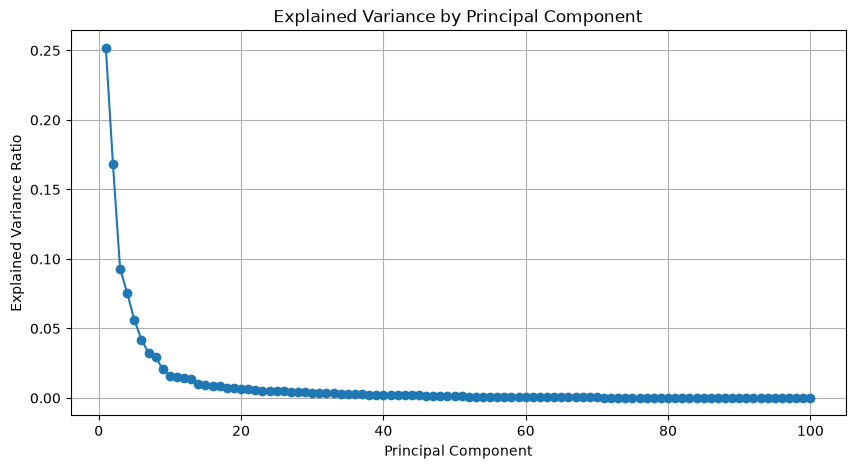

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")

plt.grid(True)
plt.show()

In [24]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.25176835 0.41999024 0.51295029 0.58845813 0.64479312 0.68681818
 0.71921107 0.74851458 0.76919807 0.78498481 0.80015131 0.81457288
 0.82818623 0.83849135 0.84808313 0.85700359 0.86562813 0.87310492
 0.88005955 0.88648201 0.89273057 0.89869165 0.90405154 0.90925159
 0.9141174  0.91893095 0.9235807  0.92789625 0.9319317  0.9358073
 0.9394551  0.94301286 0.94637825 0.94953012 0.9524363  0.95515408
 0.95771355 0.96020052 0.96262085 0.96483943 0.96695449 0.96900861
 0.97100749 0.97290846 0.97475198 0.97640107 0.97800479 0.97942599
 0.98081967 0.982079   0.98320532 0.98428501 0.98533908 0.98634029
 0.98723904 0.98805341 0.98882374 0.98955925 0.99025073 0.99091217
 0.99155284 0.99217075 0.99275364 0.99326236 0.99375272 0.99421107
 0.99464883 0.99506567 0.99546906 0.99585033 0.99620476 0.99654341
 0.99686206 0.99716764 0.99744833 0.9977043  0.99794274 0.99816731
 0.99837814 0.99857865 0.99876272 0.99893579 0.99909106 0.99923
 0.99935635 0.99947089 0.99956386 0.99964774 0.99970769 0.99976556

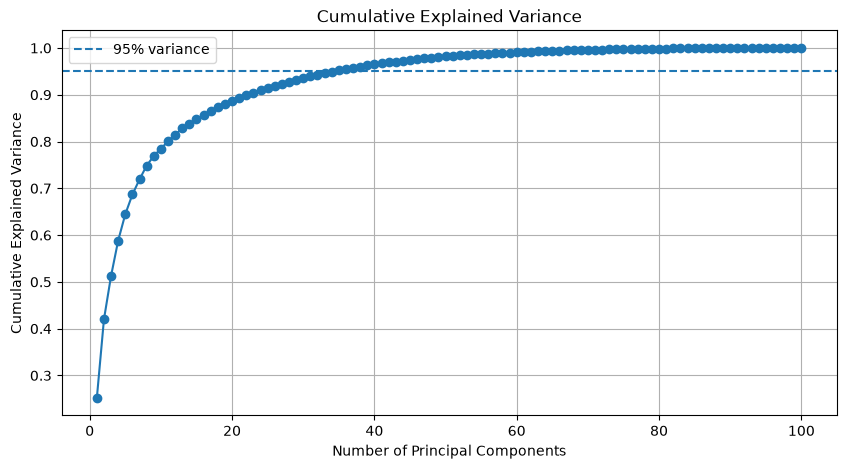

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.show()

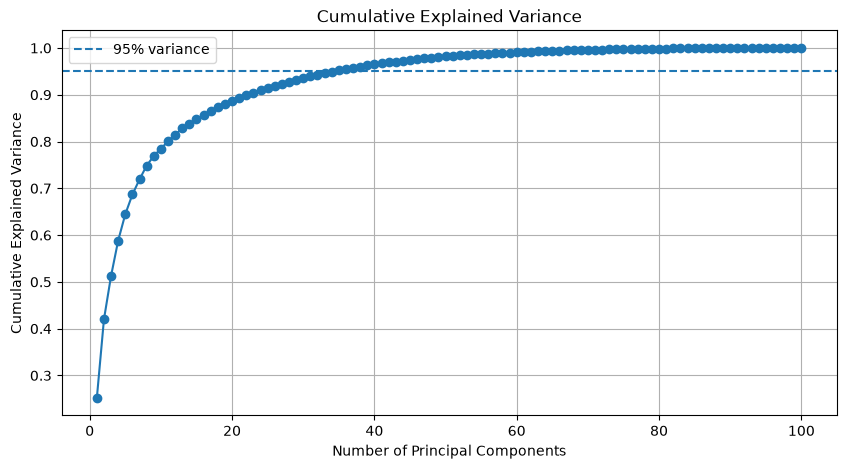

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.show()

In [27]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("Components for 90% variance:", n_components_90)
print("Components for 95% variance:", n_components_95)
print("Components for 99% variance:", n_components_99)

Components for 90% variance: 23
Components for 95% variance: 35
Components for 99% variance: 59


In [28]:
pca_final = PCA(n_components=n_components_95)

X_reduced = pca_final.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape)
print("Reduced dimensions:", X_reduced.shape)

Original dimensions: (1994, 100)
Reduced dimensions: (1994, 35)


In [29]:
pca_columns = [
    f"PC{i+1}"
    for i in range(n_components_95)
]

X_reduced_df = pd.DataFrame(
    X_reduced,
    columns=pca_columns
)

X_reduced_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35
0,1.351533,-1.025613,-3.263721,-0.908789,1.506316,-3.099673,0.214893,0.170943,-0.521276,-0.172246,...,0.692951,1.081006,0.062823,0.097876,-0.281446,0.371837,0.214691,0.109264,0.114580,-0.031143
1,-1.427641,0.512998,-4.296713,-2.068279,-2.515535,-4.663763,2.136751,1.387420,0.788250,-2.002968,...,0.068522,-0.747515,0.087512,0.178558,-1.071083,0.328409,1.115218,0.119608,0.006101,-0.806747
2,-2.123216,-2.425165,0.241725,0.325359,-0.184267,-2.337889,1.915656,-1.212712,-1.691337,-0.704867,...,0.908258,-0.016780,0.545206,0.238309,-0.268936,-0.971089,0.350988,-0.284980,-0.649273,0.087595
3,3.009967,1.971107,3.538197,0.446277,3.199006,-0.183639,4.207256,-2.762519,-2.367560,-0.751835,...,1.281689,-0.546972,0.773590,-0.509550,-1.169920,-0.124923,-0.264473,0.905623,-0.985178,1.599585
4,5.620866,-2.700288,2.767426,0.449663,1.771415,-0.527008,-0.609083,0.668700,-0.194155,-0.634693,...,-0.270108,-0.346838,0.003313,-0.357207,1.014856,-0.768372,-0.225991,0.586200,0.097220,-0.228086


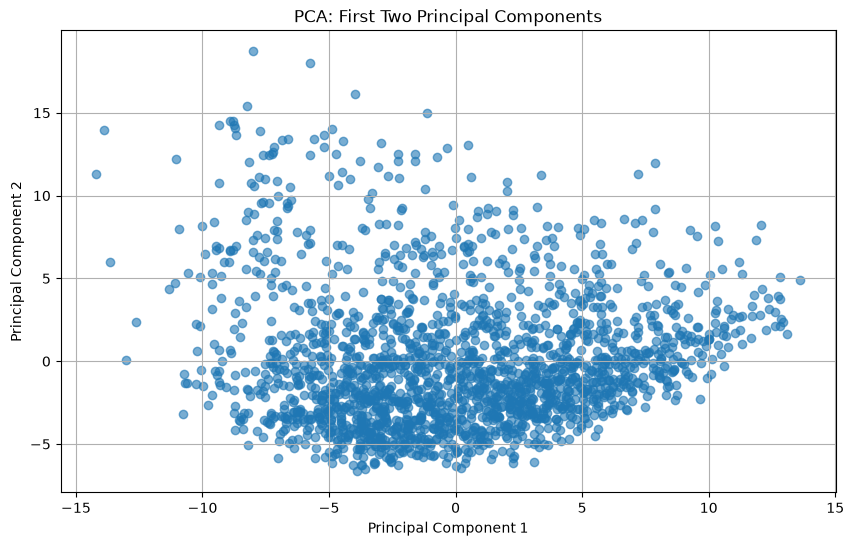

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Principal Components")

plt.grid(True)
plt.show()

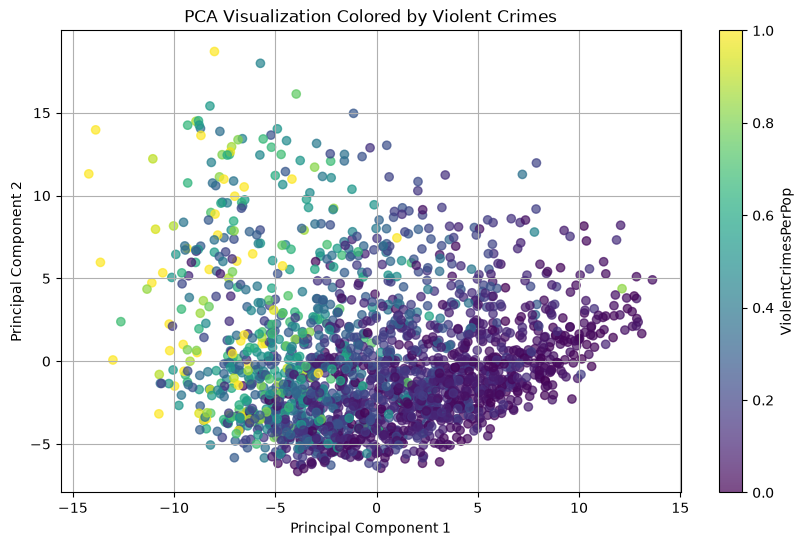

In [31]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=df[target],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization Colored by Violent Crimes")

plt.colorbar(scatter, label="ViolentCrimesPerPop")

plt.grid(True)
plt.show()

In [32]:
original_dimensions = X_scaled.shape[1]
reduced_dimensions = X_reduced.shape[1]

print("Original dimensions :", original_dimensions)
print("Reduced dimensions  :", reduced_dimensions)

reduction_percentage = (
    (original_dimensions - reduced_dimensions)
    / original_dimensions
) * 100

print(
    f"Dimensionality reduction: {reduction_percentage:.2f}%"
)

Original dimensions : 100
Reduced dimensions  : 35
Dimensionality reduction: 65.00%


In [33]:
comparison = pd.DataFrame({
    "Stage": [
        "Original Features",
        "After PCA"
    ],
    "Number of Dimensions": [
        original_dimensions,
        reduced_dimensions
    ]
})

comparison

,Stage,Number of Dimensions
0,Original Features,100
1,After PCA,35


In [34]:
final_variance = pca_final.explained_variance_ratio_.sum()

print(
    f"Variance retained: {final_variance * 100:.2f}%"
)

Variance retained: 95.24%


In [35]:
for i, variance in enumerate(
    pca_final.explained_variance_ratio_,
    start=1
):
    print(
        f"PC{i}: {variance * 100:.2f}%"
    )

PC1: 25.18%
PC2: 16.82%
PC3: 9.30%
PC4: 7.55%
PC5: 5.63%
PC6: 4.20%
PC7: 3.24%
PC8: 2.93%
PC9: 2.07%
PC10: 1.58%
PC11: 1.52%
PC12: 1.44%
PC13: 1.36%
PC14: 1.03%
PC15: 0.96%
PC16: 0.89%
PC17: 0.86%
PC18: 0.75%
PC19: 0.70%
PC20: 0.64%
PC21: 0.62%
PC22: 0.60%
PC23: 0.54%
PC24: 0.52%
PC25: 0.49%
PC26: 0.48%
PC27: 0.46%
PC28: 0.43%
PC29: 0.40%
PC30: 0.39%
PC31: 0.36%
PC32: 0.36%
PC33: 0.34%
PC34: 0.32%
PC35: 0.29%
